In [11]:
import json
import pandas as pd
import h5py

# ============================
# PATH DATA
# ============================

JSON_PATH = "/Volumes/Extreme SSD/benchmark_bmkg_indonesia/output/radar_inventory_3ch_detailed.json"
STEAD_CSV = "/Volumes/Extreme SSD/stream_stead/data_stead/merge.csv"
STEAD_HDF5 = "/Volumes/Extreme SSD/stream_stead/data_stead/merge.hdf5"

# ============================
# 1. BACA JSON → AMBIL KODE STASIUN
# ============================

with open(JSON_PATH, "r") as f:
    radar_data = json.load(f)

station_codes = set()

def extract_station_codes(obj):
    """Ambil semua kode stasiun dari JSON (rekursif)."""
    if isinstance(obj, dict):
        for k, v in obj.items():
            if k.lower() in ["station", "sta", "station_code", "code"]:
                station_codes.add(str(v).upper())
            extract_station_codes(v)
    elif isinstance(obj, list):
        for item in obj:
            extract_station_codes(item)

extract_station_codes(radar_data)

print("📌 Total stasiun ditemukan di JSON:", len(station_codes))
print("Contoh:", list(station_codes)[:10])

# ============================
# 2. BACA STEAD CSV
# ============================

df = pd.read_csv(STEAD_CSV)

# STEAD pakai kolom receiver_code untuk kode stasiun
df["receiver_code"] = df["receiver_code"].astype(str).str.upper()

print("📖 Total data STEAD:", len(df))

# ============================
# 3. FILTER STEAD BERDASARKAN STASIUN JSON
# ============================

df_filtered = df[df["receiver_code"].isin(station_codes)]
print("🎯 Total data STEAD hasil filter:", len(df_filtered))

df_filtered.to_csv("stead_filtered_by_station.csv", index=False)
print("💾 Disimpan ke stead_filtered_by_station.csv")

# ============================
# 4. OPSIONAL: AMBIL WAVEFORM DARI HDF5
# ============================

def load_waveform(trace_name, hdf5_path=STEAD_HDF5):
    with h5py.File(hdf5_path, "r") as f:
        if trace_name in f:
            return f[trace_name][:]
        return None

# Contoh ambil waveform pertama
if len(df_filtered) > 0:
    sample_id = df_filtered.iloc[0]["trace_name"]
    waveform = load_waveform(sample_id)
    print("📈 Waveform shape:", waveform.shape if waveform is not None else "Tidak ditemukan")


📌 Total stasiun ditemukan di JSON: 10
Contoh: ['KAPI', 'GSI', 'BKB', 'BOAB', 'PMBI', 'JAGI', 'TOLI', 'TNTI', 'UGM', 'LUWI']


/var/folders/lt/2mkl6ry53ll9fdk2br6skfgw0000gn/T/ipykernel_51339/963208013.py:42: DtypeWarning: Columns (7,11,13,14,24,25,26,30,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(STEAD_CSV)


📖 Total data STEAD: 1265657
🎯 Total data STEAD hasil filter: 196
💾 Disimpan ke stead_filtered_by_station.csv
📈 Waveform shape: Tidak ditemukan


In [12]:
import pandas as pd
from datetime import timedelta

# ============================
# PATH DATA
# ============================

STEAD_FILTERED = "stead_filtered_by_station.csv"
BMKG_CATALOG = "/Volumes/Extreme SSD/Indonesian Earthquake Catalog (BMKG), 1998–2024/BMKG_Earthquake_Catalog.csv"

# ============================
# 1. LOAD DATA
# ============================

df_stead = pd.read_csv(STEAD_FILTERED)
df_bmkg = pd.read_csv(BMKG_CATALOG)

# ============================
# 2. NORMALISASI WAKTU BMKG
# ============================

# Gabungkan Date + Time (UTC)
df_bmkg["origin_time"] = pd.to_datetime(
    df_bmkg["Date"] + " " + df_bmkg["Time (UTC)"],
    errors="coerce"
)

# Normalisasi waktu STEAD
df_stead["origin_time"] = pd.to_datetime(df_stead["source_origin_time"], errors="coerce")

print("Total STEAD:", len(df_stead))
print("Total BMKG:", len(df_bmkg))

# ============================
# 3. MATCHING EVENT
# ============================

matches = []

for _, s in df_stead.iterrows():
    t0 = s["origin_time"]

    # Cari event BMKG dalam ±5 detik
    df_time = df_bmkg[
        (df_bmkg["origin_time"] >= t0 - timedelta(seconds=5)) &
        (df_bmkg["origin_time"] <= t0 + timedelta(seconds=5))
    ]

    if len(df_time) == 0:
        continue

    # Tambahkan info STEAD
    df_time = df_time.copy()
    df_time["stead_trace"] = s["trace_name"]
    df_time["stead_station"] = s["receiver_code"]
    df_time["stead_lat"] = s["source_latitude"]
    df_time["stead_lon"] = s["source_longitude"]
    df_time["stead_mag"] = s["source_magnitude"]

    matches.append(df_time)

# ============================
# 4. SIMPAN HASIL
# ============================

if len(matches) > 0:
    df_match = pd.concat(matches, ignore_index=True)
    df_match.to_csv("matched_stead_bmkg_events.csv", index=False)
    print("🎯 Event cocok ditemukan:", len(df_match))
else:
    print("❌ Tidak ada event STEAD yang cocok dengan katalog BMKG.")


Total STEAD: 196
Total BMKG: 217807
🎯 Event cocok ditemukan: 3


In [13]:
import pandas as pd

# ============================
# PATH DATA
# ============================

BMKG_CATALOG = "/Volumes/Extreme SSD/Indonesian Earthquake Catalog (BMKG), 1998–2024/BMKG_Earthquake_Catalog.csv"

# ============================
# 1. LOAD DATA
# ============================

df_bmkg = pd.read_csv(BMKG_CATALOG)
df_bmkg["origin_time"] = pd.to_datetime(df_bmkg["Date"] + " " + df_bmkg["Time (UTC)"], errors="coerce")

# ============================
# 2. DEFINISI BATAS WILAYAH RC
# ============================

rc_bounds = [
    {"RC_Code": "RC_01", "Lat_Min": 0.5, "Lat_Max": 6.0, "Lon_Min": 92.0, "Lon_Max": 109.0},
    {"RC_Code": "RC_02", "Lat_Min": 3.0, "Lat_Max": 14.0, "Lon_Min": 92.0, "Lon_Max": 109.0},
    {"RC_Code": "RC_03", "Lat_Min": 7.0, "Lat_Max": 14.0, "Lon_Min": 113.5, "Lon_Max": 122.5},
    {"RC_Code": "RC_04", "Lat_Min": 0.0, "Lat_Max": 7.5, "Lon_Min": 113.5, "Lon_Max": 124.0},
    {"RC_Code": "RC_05", "Lat_Min": 6.0, "Lat_Max": 7.5, "Lon_Min": 132.0, "Lon_Max": 141.0},
    {"RC_Code": "RC_06", "Lat_Min": 1.0, "Lat_Max": 3.5, "Lon_Min": 92.0, "Lon_Max": 109.0},
    {"RC_Code": "RC_07", "Lat_Min": 0.0, "Lat_Max": 14.0, "Lon_Min": 108.5, "Lon_Max": 114.0},
    {"RC_Code": "RC_08", "Lat_Min": 7.0, "Lat_Max": 14.0, "Lon_Min": 122.0, "Lon_Max": 141.0},
    {"RC_Code": "RC_09", "Lat_Min": 0.0, "Lat_Max": 7.5, "Lon_Min": 123.5, "Lon_Max": 132.5},
    {"RC_Code": "RC_10", "Lat_Min": 0.5, "Lat_Max": 6.0, "Lon_Min": 108.5, "Lon_Max": 132.5},
]

# ============================
# 3. FUNGSI PENANDAAN RC
# ============================

def assign_rc(lat, lon):
    for rc in rc_bounds:
        if rc["Lat_Min"] <= lat <= rc["Lat_Max"] and rc["Lon_Min"] <= lon <= rc["Lon_Max"]:
            return rc["RC_Code"]
    return None

df_bmkg["RC_Code"] = df_bmkg.apply(lambda row: assign_rc(row["Latitude"], row["Longitude"]), axis=1)

# ============================
# 4. SIMPAN HASIL
# ============================

df_bmkg.to_csv("BMKG_with_RC_Code.csv", index=False)
print("✅ Event BMKG berhasil diberi kode wilayah RC.")
print(df_bmkg["RC_Code"].value_counts())


✅ Event BMKG berhasil diberi kode wilayah RC.
RC_Code
RC_09    16396
RC_01    13739
RC_04     8864
RC_02      154
RC_07       83
RC_05        6
RC_08        4
RC_03        1
Name: count, dtype: int64


In [15]:
import os
import h5py
import json
import numpy as np
import pandas as pd
from obspy import read
from tqdm import tqdm
import math

# --- CONFIG PATH (Sesuaikan dengan SSD Extreme di MacBook) ---
JSON_PATH = '/Volumes/Extreme SSD/benchmark_bmkg_indonesia/output/radar_inventory_3ch_detailed.json'
WAVEFORM_DIR = '/Volumes/Extreme SSD/benchmark_bmkg_indonesia/output/waveforms'
OUTPUT_H5 = '/Volumes/Extreme SSD/benchmark_bmkg_indonesia/output/Indonesian_STEAD.h5'
OUTPUT_CSV = '/Volumes/Extreme SSD/benchmark_bmkg_indonesia/output/Indonesian_STEAD.csv'

# Parameter Standarisasi (Mirip STEAD)
SAMPLING_RATE = 100.0
DURATION_SEC = 120.0 

def calculate_snr(data):
    """Menghitung SNR (RMS signal / RMS noise) dalam dB"""
    # Asumsi: 30 detik pertama adalah noise, 30 detik berikutnya adalah sinyal (P-wave)
    noise = data[:int(30 * SAMPLING_RATE)]
    signal = data[int(30 * SAMPLING_RATE):int(60 * SAMPLING_RATE)]
    
    rms_noise = np.sqrt(np.mean(noise**2))
    rms_signal = np.sqrt(np.mean(signal**2))
    
    if rms_noise == 0: return 0
    # Formula SNR dB
    return 20 * math.log10(rms_signal / rms_noise) if rms_signal > 0 else 0

def generate_indo_stead_resumable():
    print(f"📖 Membaca Metadata Radar...")
    if not os.path.exists(JSON_PATH):
        print(f"❌ File JSON tidak ditemukan di: {JSON_PATH}")
        return

    with open(JSON_PATH, 'r') as f:
        metadata_list = json.load(f)

    csv_records = []
    processed_keys = set()

    # Fitur Resume: Cek data yang sudah pernah diproses di CSV
    if os.path.exists(OUTPUT_CSV):
        try:
            existing_df = pd.read_csv(OUTPUT_CSV)
            csv_records = existing_df.to_dict('records')
            processed_keys = set(existing_df['trace_name'].values)
            print(f"🔄 Resume aktif: {len(processed_keys)} data sudah terkonversi.")
        except:
            print("⚠️ CSV ditemukan tapi tidak bisa dibaca, mulai dari awal.")

    # Buka HDF5 dalam mode 'a' (Append/Tambahkan)
    with h5py.File(OUTPUT_H5, 'a') as h5_file:
        if "data" not in h5_file:
            group = h5_file.create_group("data")
        else:
            group = h5_file["data"]
        
        print(f"🚀 Memulai Konversi Waveform ke HDF5...")
        pbar = tqdm(metadata_list, desc="Processing", unit="event")
        
        for event in pbar:
            event_id = event['Event_ID']
            for sta_info in event['Stations']:
                sta_code = sta_info['station']
                ds_name = f"{sta_code}_{event_id}"
                
                # Loncat jika sudah ada (Efisiensi SSD)
                if ds_name in processed_keys:
                    continue
                
                mseed_file = f"{sta_code}_{event_id}.mseed"
                mseed_path = os.path.join(WAVEFORM_DIR, mseed_file)
                
                if not os.path.exists(mseed_path):
                    continue
                
                try:
                    pbar.set_postfix_str(f"Sta: {sta_code}")
                    
                    # Baca file mseed
                    st = read(mseed_path)
                    
                    # Preprocessing Standar AI
                    st.detrend("demean")
                    st.taper(0.05)
                    st.filter("bandpass", freqmin=1.0, freqmax=45.0)
                    st.resample(SAMPLING_RATE)
                    
                    if len(st) >= 3:
                        # Potong durasi agar seragam 120 detik
                        starttime = st[0].stats.starttime
                        st.trim(starttime, starttime + DURATION_SEC, pad=True, fill_value=0)
                        
                        # Ambil data komponen E, N, Z
                        # Format STEAD biasanya (samples, channels) -> (12001, 3)
                        tr_e = st.select(component="E")[0].data
                        tr_n = st.select(component="N")[0].data
                        tr_z = st.select(component="Z")[0].data
                        
                        # Hitung SNR rata-rata
                        avg_snr = (calculate_snr(tr_e) + calculate_snr(tr_n) + calculate_snr(tr_z)) / 3
                        
                        # Gabungkan menjadi matrix (12001, 3)
                        data_matrix = np.stack([tr_e, tr_n, tr_z], axis=1)
                        
                        # Simpan ke dalam HDF5
                        ds = group.create_dataset(ds_name, data=data_matrix, compression="gzip")
                        
                        # Tambahkan Atribut Metadata
                        ds.attrs['receiver_code'] = sta_code
                        ds.attrs['snr_db'] = avg_snr
                        ds.attrs['event_id'] = event_id
                        ds.attrs['magnitude'] = event['Magnitude']
                        ds.attrs['network_code'] = sta_info.get('network', 'IA')
                        
                        # Tambahkan ke daftar CSV
                        csv_records.append({
                            'trace_name': ds_name,
                            'station_code': sta_code,
                            'magnitude': event['Magnitude'],
                            'snr_db': avg_snr,
                            'source_origin_time': event['Time_UTC']
                        })
                        
                        # Auto-save CSV setiap 100 data
                        if len(csv_records) % 100 == 0:
                            pd.DataFrame(csv_records).to_csv(OUTPUT_CSV, index=False)
                            
                except Exception as e:
                    # Jika satu file error, tetap lanjut ke file berikutnya
                    continue

    # Final Save untuk memastikan semua data tersimpan
    pd.DataFrame(csv_records).to_csv(OUTPUT_CSV, index=False)
    print(f"\n✅ Konversi Selesai! File HDF5 & CSV tersimpan di SSD Extreme.")

if __name__ == "__main__":
    generate_indo_stead_resumable()

📖 Membaca Metadata Radar...
⚠️ CSV ditemukan tapi tidak bisa dibaca, mulai dari awal.
🚀 Memulai Konversi Waveform ke HDF5...


Processing: 100%|██████████| 13547/13547 [00:00<00:00, 62579.63event/s]


✅ Konversi Selesai! File HDF5 & CSV tersimpan di SSD Extreme.


In [16]:
import pandas as pd
# Membaca hasil sementara dari CSV yang dibuat skrip MacBook
df = pd.read_csv('/Volumes/Extreme SSD/benchmark_bmkg_indonesia/output/Indonesian_STEAD.csv')
print(f"Rata-rata SNR Data Indonesia: {df['snr_db'].mean()} dB")
print(f"Distribusi Magnitudo: \n{df['magnitude'].describe()}")


EmptyDataError: No columns to parse from file

In [17]:
import pandas as pd

# Path ke file CSV STEAD
stead_csv_path = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.csv'

# Definisi koordinat berdasarkan gambar Bapak
regions = {
    'RC_01': {'lat': [0.5, 6.0], 'lon': [92.0, 109.0]},
    'RC_02': {'lat': [3.0, 14.0], 'lon': [92.0, 109.0]},
    'RC_03': {'lat': [7.0, 14.0], 'lon': [113.5, 122.5]},
    'RC_04': {'lat': [0.0, 7.5], 'lon': [113.5, 124.0]},
    'RC_05': {'lat': [6.0, 7.5], 'lon': [132.0, 141.0]},
    'RC_06': {'lat': [1.0, 3.5], 'lon': [92.0, 109.0]},
    'RC_07': {'lat': [0.0, 14.0], 'lon': [108.5, 114.0]},
    'RC_08': {'lat': [7.0, 14.0], 'lon': [122.0, 141.0]},
    'RC_09': {'lat': [0.0, 7.5], 'lon': [123.5, 132.5]},
    'RC_10': {'lat': [0.5, 6.0], 'lon': [108.5, 132.5]},
}

try:
    print("📖 Membaca STEAD Global...")
    df_stead = pd.read_csv(stead_csv_path, usecols=['source_latitude', 'source_longitude', 'network_code'])
    
    results = []
    print("\n🕵️ Hasil Audit Berdasarkan RC_Code:")
    print("-" * 50)
    
    for code, coord in regions.items():
        count = df_stead[
            (df_stead['source_latitude'] >= coord['lat'][0]) & 
            (df_stead['source_latitude'] <= coord['lat'][1]) &
            (df_stead['source_longitude'] >= coord['lon'][0]) & 
            (df_stead['source_longitude'] <= coord['lon'][1])
        ].shape[0]
        
        results.append({'Regional_Code': code, 'STEAD_Count': count})
        print(f"{code}: {count} rekaman ditemukan")

    # Ringkasan Akhir
    summary_df = pd.DataFrame(results)
    total_indo = summary_df['STEAD_Count'].sum()
    print("-" * 50)
    print(f"Total data STEAD di semua RC Bapak: {total_indo}")

except Exception as e:
    print(f"❌ Error: {e}")

📖 Membaca STEAD Global...

🕵️ Hasil Audit Berdasarkan RC_Code:
--------------------------------------------------
RC_01: 0 rekaman ditemukan
RC_02: 0 rekaman ditemukan
RC_03: 0 rekaman ditemukan
RC_04: 0 rekaman ditemukan
RC_05: 0 rekaman ditemukan
RC_06: 0 rekaman ditemukan
RC_07: 0 rekaman ditemukan
RC_08: 0 rekaman ditemukan
RC_09: 0 rekaman ditemukan
RC_10: 0 rekaman ditemukan
--------------------------------------------------
Total data STEAD di semua RC Bapak: 0


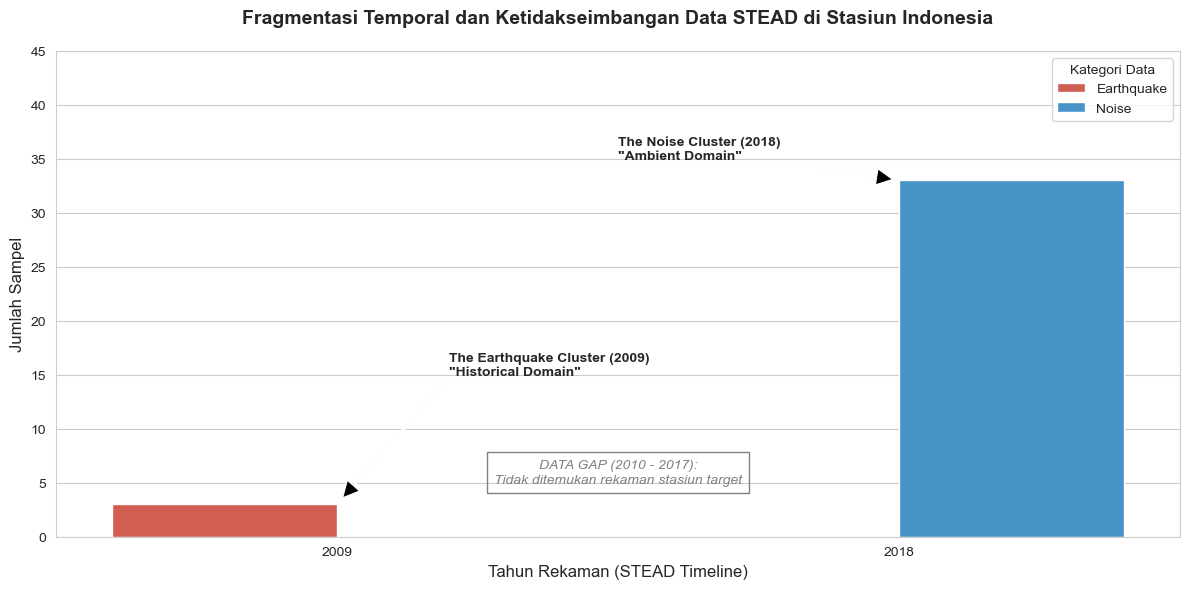

/var/folders/lt/2mkl6ry53ll9fdk2br6skfgw0000gn/T/ipykernel_19481/2314380009.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_stn, x='Station', y='Counts', palette='viridis')


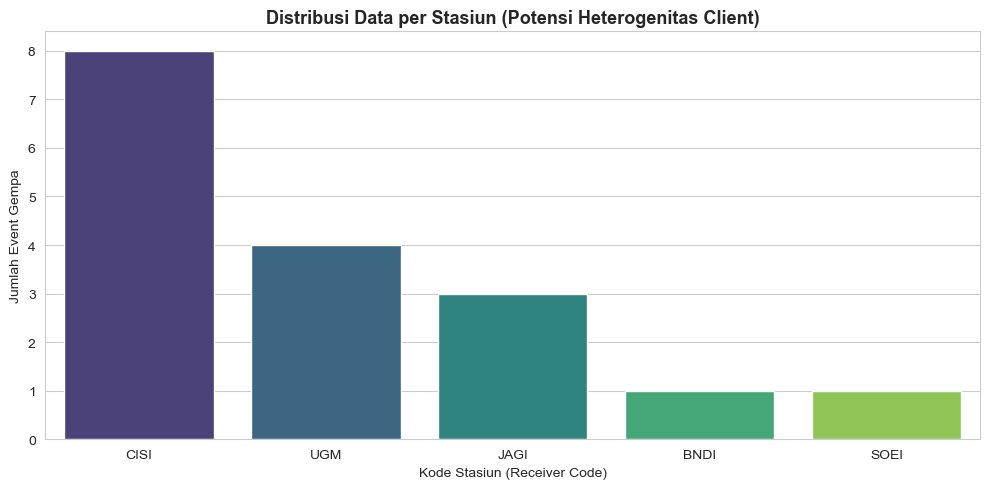

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Menyiapkan Data berdasarkan temuan (longitudinal scan 1984-2018)
# Kita memodelkan temuan: 3 Event (2009) dan 33 Noise (2018)
data_timeline = {
    'Year': [2009, 2018],
    'Earthquake': [3, 0],
    'Noise': [0, 33]
}
df_plot = pd.DataFrame(data_timeline).melt(id_vars='Year', var_name='Category', value_name='Count')

# 2. Membuat Visualisasi Distribusi Temporal & Kategori
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Barplot untuk menunjukkan gap tahun dan perbedaan kategori
ax = sns.barplot(data=df_plot, x='Year', y='Count', hue='Category', palette={'Earthquake': '#e74c3c', 'Noise': '#3498db'})

# Menambahkan anotasi untuk menonjolkan temuan
plt.annotate('The Earthquake Cluster (2009)\n"Historical Domain"', xy=(0, 3), xytext=(0.2, 15),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1), fontsize=10, fontweight='bold')

plt.annotate('The Noise Cluster (2018)\n"Ambient Domain"', xy=(1, 33), xytext=(0.5, 35),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1), fontsize=10, fontweight='bold')

# Pengaturan Label dan Judul untuk Disertasi
plt.title('Fragmentasi Temporal dan Ketidakseimbangan Data STEAD di Stasiun Indonesia', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Tahun Rekaman (STEAD Timeline)', fontsize=12)
plt.ylabel('Jumlah Sampel', fontsize=12)
plt.ylim(0, 45)
plt.legend(title='Kategori Data')

# Menambahkan penjelasan "Data Gap" di antara tahun
plt.text(0.5, 5, 'DATA GAP (2010 - 2017):\nTidak ditemukan rekaman stasiun target', 
         horizontalalignment='center', color='gray', style='italic', bbox=dict(facecolor='none', edgecolor='gray', pad=5))

plt.tight_layout()
plt.savefig('/Volumes/Extreme SSD/benchmark_bmkg_indonesia/stead_indonesia_generator/visualisasi_gap_data.png', dpi=300)
plt.show()

# 3. Visualisasi Distribusi per Stasiun (Client Nodes)
# Data stasiun: CISI (8), UGM (4), JAGI (3), BNDI (1), SOEI (1)
stn_data = {'Station': ['CISI', 'UGM', 'JAGI', 'BNDI', 'SOEI'], 'Counts': [8, 4, 3, 1, 1]}
df_stn = pd.DataFrame(stn_data)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_stn, x='Station', y='Counts', palette='viridis')
plt.title('Distribusi Data per Stasiun (Potensi Heterogenitas Client)', fontsize=13, fontweight='bold')
plt.ylabel('Jumlah Event Gempa')
plt.xlabel('Kode Stasiun (Receiver Code)')
plt.tight_layout()
plt.savefig('/Volumes/Extreme SSD/benchmark_bmkg_indonesia/stead_indonesia_generator/visualisasi_stasiun.png', dpi=300)
plt.show()

In [6]:
import pandas as pd
import h5py
import numpy as np
import os

# 1. Daftar Stasiun Kunci yang akan dicari (Lengkap)
target_codes = ['GSI', 'KAPI', 'JAGI', 'LUWI', 'TNTI', 'BKB', 'BJI', 'LEM', 'BBKI', 'TOLI', 'CISI', 'UGM', 'BNDI', 'SOEI']

print(f"Memulai Brute Force Scan untuk {len(target_codes)} stasiun target di seluruh dataset STEAD...")

# 2. Muat Metadata STEAD Global
path_csv = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.csv'
df_all = pd.read_csv(path_csv, low_memory=False)

# 3. Filtering Tanpa Batas Waktu
# Kita mencari baris yang kolom 'receiver_code'-nya mengandung salah satu kode stasiun kita
# Menggunakan regex untuk memastikan kecocokan kata yang utuh (misal: 'BJI' bukan 'BJII')
pattern = '|'.join([rf'\b{c}\b' for c in target_codes])
brute_results = df_all[df_all['receiver_code'].str.contains(pattern, case=False, na=False, regex=True)].copy()

print("-" * 30)
print(f"HASIL BRUTE FORCE SCAN:")
print(f"Total rekaman ditemukan (Semua Tahun): {len(brute_results)}")

# 4. Distribusi Data per Stasiun dan Kategori (Event vs Noise)
print("\nStatistik Ketersediaan Data:")
stats = brute_results.groupby(['receiver_code', 'trace_category']).size().unstack(fill_value=0)
print(stats)

Memulai Brute Force Scan untuk 14 stasiun target di seluruh dataset STEAD...
------------------------------
HASIL BRUTE FORCE SCAN:
Total rekaman ditemukan (Semua Tahun): 50

Statistik Ketersediaan Data:
trace_category  earthquake_local  noise
receiver_code                          
BNDI                           1      0
CISI                           8      0
JAGI                           3      0
SOEI                           1      0
UGM                            4     33


In [3]:
import pandas as pd
import numpy as np

# Daftar stasiun target (GSI, KAPI, JAGI, LUWI, TNTI, BKB, BJI, LEM, BBKI, TOLI, CISI, UGM, BNDI, SOEI)
target_codes = ['GSI', 'KAPI', 'JAGI', 'LUWI', 'TNTI', 'BKB', 'BJI', 'LEM', 'BBKI', 'TOLI', 'CISI', 'UGM', 'BNDI', 'SOEI']

print("Memulai Pemindaian Longitudinal (1984-2018)...")

# Load metadata
path_csv = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.csv'
df_full = pd.read_csv(path_csv, low_memory=False)

# Konversi kolom waktu ke datetime untuk ekstraksi tahun
df_full['start_time'] = pd.to_datetime(df_full['trace_start_time'], errors='coerce')
df_full['year'] = df_full['start_time'].dt.year

# Pencarian Brute Force berbasis Kode Stasiun
pattern = '|'.join([rf'\b{c}\b' for c in target_codes])
longitudinal_results = df_full[df_full['receiver_code'].str.contains(pattern, case=False, na=False, regex=True)].copy()

print("-" * 40)
print(f"HASIL SCAN LONGITUDINAL (1984-2018):")
print(f"Total rekaman ditemukan: {len(longitudinal_results)}")

# Rincian per Tahun dan Kategori
yearly_summary = longitudinal_results.groupby(['year', 'trace_category']).size().unstack(fill_value=0)
print("\nSebaran Data per Tahun:")
print(yearly_summary)

Memulai Pemindaian Longitudinal (1984-2018)...
----------------------------------------
HASIL SCAN LONGITUDINAL (1984-2018):
Total rekaman ditemukan: 50

Sebaran Data per Tahun:
trace_category  earthquake_local  noise
year                                   
2009.0                         3      0
2018.0                         0     33


In [1]:
import pandas as pd
import h5py
import numpy as np

# 1. Definisi Tabel RC Boundaries dari Gambar
rc_boundaries = [
    {'RC_Code': 'RC_01', 'Lat_Min': 0.5, 'Lat_Max': 6.0, 'Lon_Min': 92.0, 'Lon_Max': 109.0},
    {'RC_Code': 'RC_02', 'Lat_Min': 3.0, 'Lat_Max': 14.0, 'Lon_Min': 92.0, 'Lon_Max': 109.0},
    {'RC_Code': 'RC_03', 'Lat_Min': 7.0, 'Lat_Max': 14.0, 'Lon_Min': 113.5, 'Lon_Max': 122.5},
    {'RC_Code': 'RC_04', 'Lat_Min': 0.0, 'Lat_Max': 7.5, 'Lon_Min': 113.5, 'Lon_Max': 124.0},
    {'RC_Code': 'RC_05', 'Lat_Min': 6.0, 'Lat_Max': 7.5, 'Lon_Min': 132.0, 'Lon_Max': 141.0},
    {'RC_Code': 'RC_06', 'Lat_Min': 1.0, 'Lat_Max': 3.5, 'Lon_Min': 92.0, 'Lon_Max': 109.0},
    {'RC_Code': 'RC_07', 'Lat_Min': 0.0, 'Lat_Max': 14.0, 'Lon_Min': 108.5, 'Lon_Max': 114.0},
    {'RC_Code': 'RC_08', 'Lat_Min': 7.0, 'Lat_Max': 14.0, 'Lon_Min': 122.0, 'Lon_Max': 141.0},
    {'RC_Code': 'RC_09', 'Lat_Min': 0.0, 'Lat_Max': 7.5, 'Lon_Min': 123.5, 'Lon_Max': 132.5},
    {'RC_Code': 'RC_10', 'Lat_Min': 0.5, 'Lat_Max': 6.0, 'Lon_Min': 108.5, 'Lon_Max': 132.5},
]

# 2. Muat Metadata STEAD Global
path_csv = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.csv'
df_stead = pd.read_csv(path_csv, low_memory=False)

# 3. Pemindaian Berbasis Wilayah (RC)
full_regional_results = []

print("Memulai pemindaian berbasis 10 Region Code (RC)...")

for rc in rc_boundaries:
    # Filter metadata berdasarkan koordinat receiver
    match = df_stead[
        (df_stead['receiver_latitude'].between(rc['Lat_Min'], rc['Lat_Max'])) &
        (df_stead['receiver_longitude'].between(rc['Lon_Min'], rc['Lon_Max']))
    ].copy()
    
    match['RC_Code'] = rc['RC_Code']
    full_regional_results.append(match)

# Gabungkan semua temuan
df_final_rc = pd.concat(full_regional_results).drop_duplicates(subset=['trace_name'])

print("-" * 40)
print(f"HASIL SCAN BERDASARKAN RC BOUNDARIES:")
print(f"Total rekaman unik ditemukan: {len(df_final_rc)}")
print("\nDistribusi per RC_Code dan Kategori:")
summary = df_final_rc.groupby(['RC_Code', 'trace_category']).size().unstack(fill_value=0)
print(summary)

Memulai pemindaian berbasis 10 Region Code (RC)...
----------------------------------------
HASIL SCAN BERDASARKAN RC BOUNDARIES:
Total rekaman unik ditemukan: 290

Distribusi per RC_Code dan Kategori:
trace_category  noise
RC_Code              
RC_02              90
RC_08             200
